In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [181]:
df=pd.read_csv(r"C:\Users\abhis\Downloads\mymoviedb.csv",engine='python')

In [182]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [184]:
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
df = df.dropna(subset=['Vote_Count', 'Vote_Average'])

In [185]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [186]:
df.duplicated().sum()

np.int64(0)

### Exploration Summary
* we have a dataframe consisting of 9827 rows and 9 columns.
* our dataset looks a bit tidy with no NaNs nor duplicated values.
* Release_Date column needs to be casted into date time and to extract only the year value.
* Overview, Original_Language and Poster_Url don't be so useful during analysis, so we'll drop them.
* there is noticeable outliers in Popularity column.
* Vote_Average better be categorised for proper analysis.
* Genre column has comma separated values and white spaces that needs to be handled and casted into category.

In [187]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtype)

datetime64[ns]


In [188]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtype

dtype('int32')

In [189]:
df['Release_Date'] = df['Release_Date'].astype('Int64')

In [190]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [191]:
# dropping the column
col=['Overview','Overview','Poster_Url']
df.drop(col,axis=1,inplace=True)


In [192]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Original_Language', 'Genre'],
      dtype='object')

In [193]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,6.3,en,Thriller
3,2021,Encanto,2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War"


### ### Categorizing Vote_Average Column

* We would cut the Vote_Average values and make 4 categories:popular, average, below_avg, not_popular to describe it more using categorize_col() function provided above

In [194]:
def categorize_col(df, col, labels):
    
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]
    
    df[col] = pd.cut(df[col], bins=edges, labels=labels, duplicates='drop')
    return df

In [195]:
labels=('not_popular','below_avg','average','popular')
categorize_col(df,'Vote_Average', labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [196]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,popular,en,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,below_avg,en,Thriller
3,2021,Encanto,2402.201,5076.0,popular,en,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,average,en,"Action, Adventure, Thriller, War"


In [197]:
 df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

In [198]:
df.dropna(inplace=True)
df.isnull().sum()

Release_Date         0
Title                0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
dtype: int64

### we'd split genres into a list and then explode our dataframe to have only one genre per row for each movie

In [199]:
df['Genre']=df['Genre'].str.split(', ')

df=df.explode('Genre').reset_index(drop=True)
df.head() 

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Science Fiction
3,2022,The Batman,3827.658,1151.0,popular,en,Crime
4,2022,The Batman,3827.658,1151.0,popular,en,Mystery


In [203]:
df['Genre']=df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Release_Date       25551 non-null  Int64   
 1   Title              25551 non-null  object  
 2   Popularity         25551 non-null  float64 
 3   Vote_Count         25551 non-null  float64 
 4   Vote_Average       25551 non-null  category
 5   Original_Language  25551 non-null  object  
 6   Genre              25551 non-null  category
dtypes: Int64(1), category(2), float64(2), object(2)
memory usage: 1.0+ MB


In [205]:
df.nunique()

Release_Date          100
Title                9414
Popularity           8087
Vote_Count           3265
Vote_Average            4
Original_Language      42
Genre                  19
dtype: int64

In [206]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Science Fiction
3,2022,The Batman,3827.658,1151.0,popular,en,Crime
4,2022,The Batman,3827.658,1151.0,popular,en,Mystery


# data visulization

In [207]:
sns.set_style('whitegrid')

## what is most frequnet genre of movies relesed on netflix?

In [209]:
df['Genre'].describe()

count     25551
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

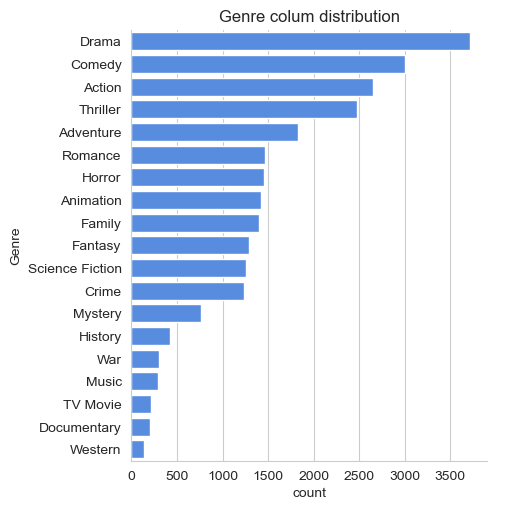

In [210]:
sns.catplot(y='Genre',data=df,kind='count',
           order=df['Genre'].value_counts().index,
           color='#4287f5')
plt.title('Genre2 colum distribution')
plt.show()

## which has highest votes in vote avg column?

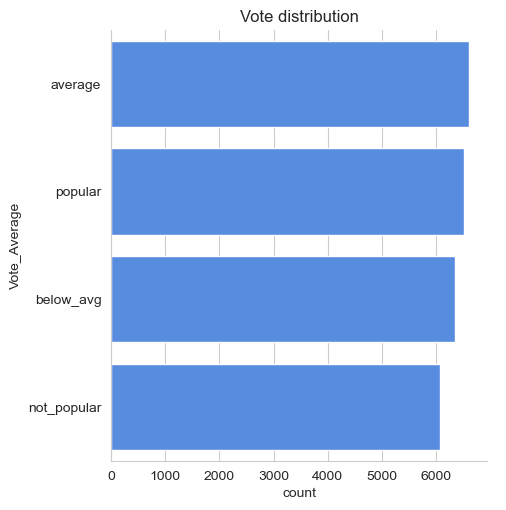

In [213]:
sns.catplot(y='Vote_Average',data=df,kind='count',
           order=df['Vote_Average'].value_counts().index,
           color='#4287f5')
plt.title('Vote distribution')
plt.show()

## what movie got highest popularity ?what is genre?

In [215]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Adventure


In [217]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,en,Science Fiction


## what movie got lowest popularity ?what is genre?

In [218]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
25545,2021,The United States vs. Billie Holiday,13.354,152.0,average,en,Music
25546,2021,The United States vs. Billie Holiday,13.354,152.0,average,en,Drama
25547,2021,The United States vs. Billie Holiday,13.354,152.0,average,en,History
25548,1984,Threads,13.354,186.0,popular,en,War
25549,1984,Threads,13.354,186.0,popular,en,Drama
25550,1984,Threads,13.354,186.0,popular,en,Science Fiction


## which year has the most filmmed movies?

C:\Users\abhis\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


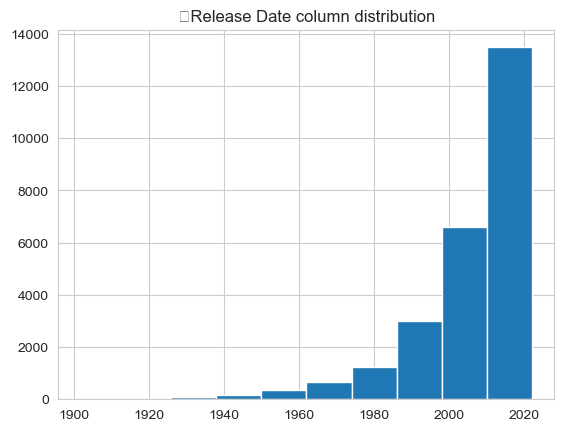

In [220]:
df['Release_Date'].hist()
plt.title("	Release Date column distribution")
plt.show()

# Conclusion

Q1: What is the most frequent genre in the dataset?
Drama genre is the most frequent genre in our dataset and has appeared more than 14% of the times among 19 other genres.

Q2: What genre has highest votes?
We have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the highest popularity among fans by having more than 18.5% of movies.

Q3: Which movie got the highest popularity? what’s its genre?
Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of Action, Adventure and Science Fiction.

Q4: What movie got the lowest popularity? what’s its genre?
The United States, Thread has the highest lowest rate in our dataset and it has genres of music, drama, war, sci-fi and history.

Q5: Which year has the most filmed movies?
Year 2020 has the highest filming rate in our dataset.